# IBM Telco Customer Churn Prediction using Machine Learning

### 1. Import Libraries

In [29]:
# Basic
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Preprocessing
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Model Selection
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
)

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Save model
import joblib

### 2. Load Dataset

In [30]:
df= pd.read_csv("Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 3. Initial Inspection

In [31]:
df.shape

(7043, 21)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [33]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [34]:
df.drop(columns=['customerID'], inplace=True, errors='ignore')

df.sample(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
511,Male,0,No,No,61,Yes,Yes,Fiber optic,Yes,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,106.45,6300.15,No
1718,Female,0,No,No,17,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Bank transfer (automatic),19.90,323.15,No
903,Female,0,Yes,No,56,Yes,No,Fiber optic,Yes,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),105.60,6068.65,No
1950,Male,0,Yes,No,65,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),91.85,5940.85,Yes
4632,Female,0,Yes,Yes,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.45,19.45,Yes


### 4. Data Cleaning

In [35]:
# IBM Telco Specific Fix
# TotalCharges(object --> float64)
# (error = coerce) ensures invalid values conversion to NaN
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [36]:
# Missing Values
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

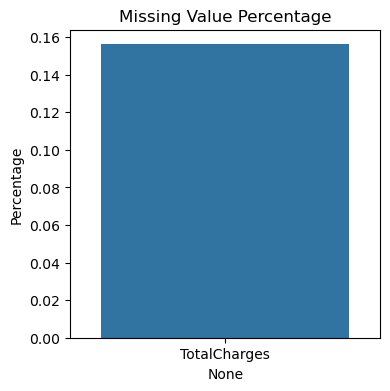

In [37]:
# Visualize Missing Values
missing_percent = (
    df.isnull().sum() /
    len(df)
) * 100

missing_percent = missing_percent[
    missing_percent > 0
]
plt.figure(figsize=(4,4))

sns.barplot(
    x=missing_percent.index,
    y=missing_percent.values
)

plt.ylabel("Percentage")

plt.title(
    "Missing Value Percentage"
)

plt.show()

In [38]:
# Fill Missing Values(Alternate - Simple Imputer)
df['TotalCharges'].fillna(
    df['TotalCharges'].median(),
    inplace=True
)

df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [39]:
# Check Duplicates
duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed")
else:
    print("No duplicate records found")

Duplicate Rows: 22
Duplicates removed


### 5.Exploratory Data Analysis

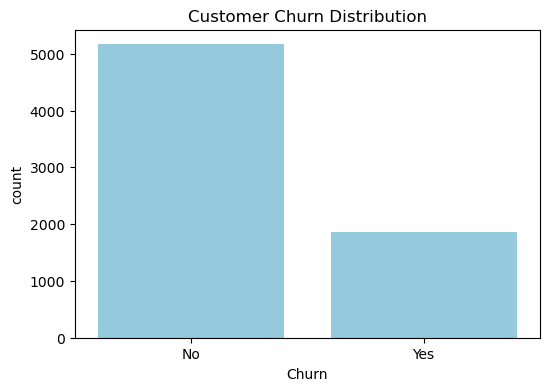

In [40]:
# Target Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, color='skyblue')
plt.title("Customer Churn Distribution")
plt.show()

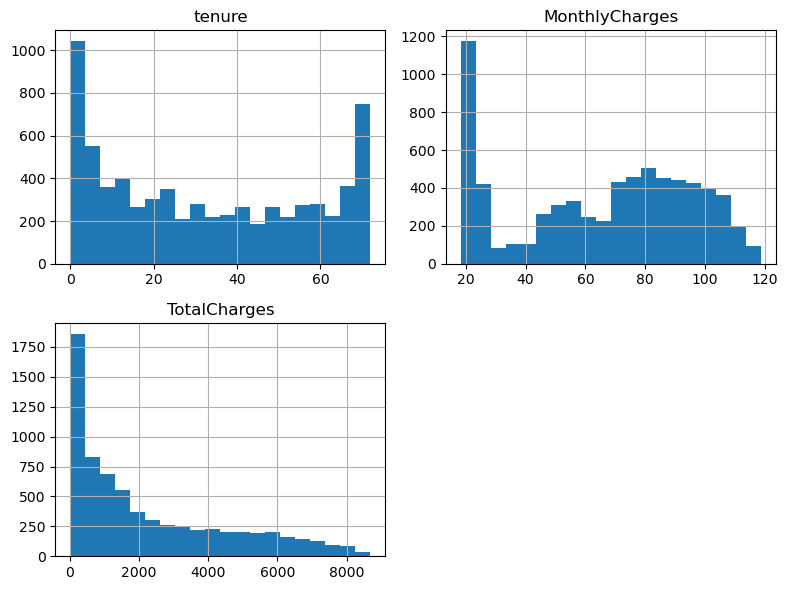

In [41]:
# Numerical Features
num_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

df[num_cols].hist(
    figsize=(8,6),
    bins=20
)

plt.tight_layout()
plt.show()

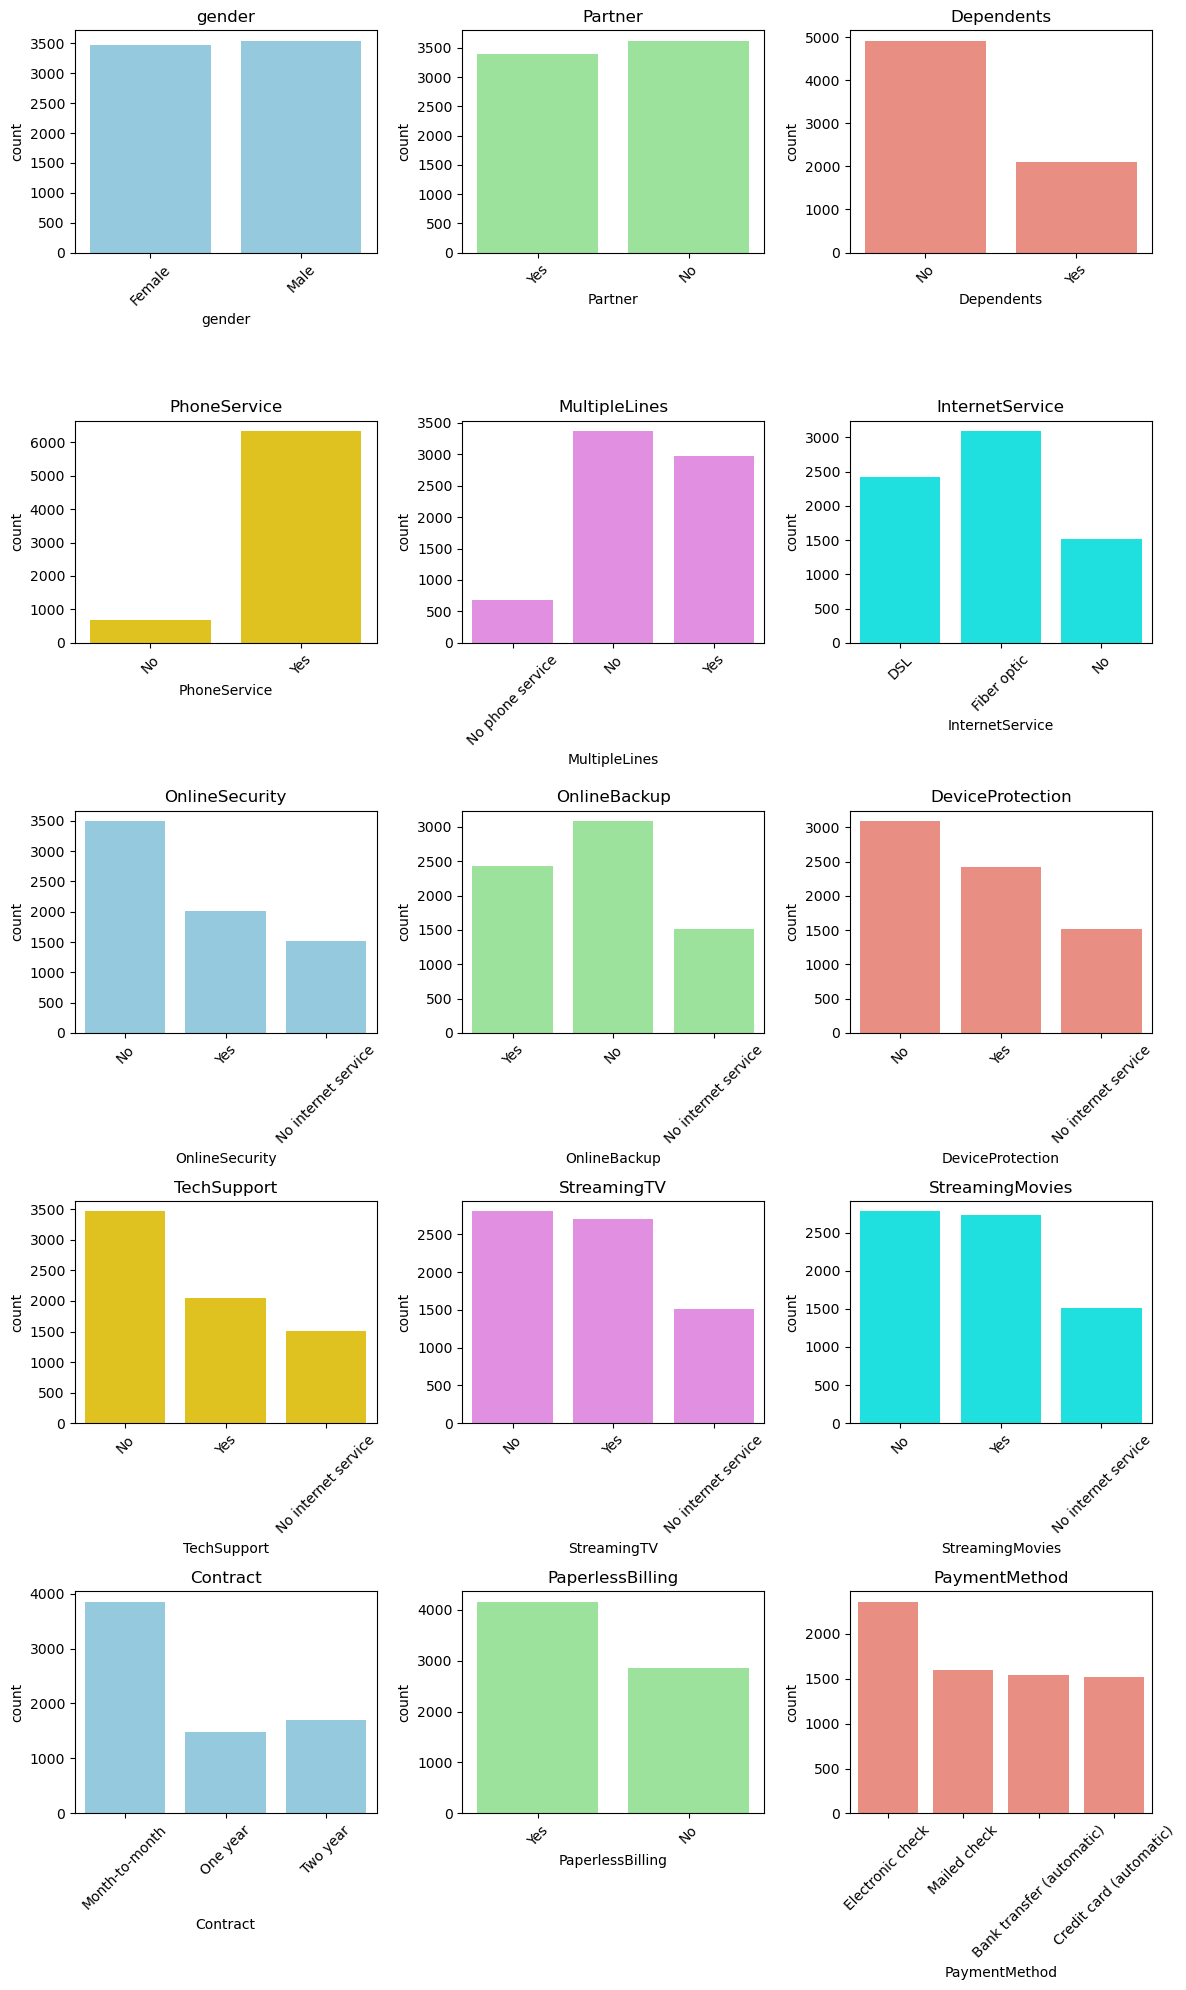

In [42]:
# Categorical Features
cat_cols = df.select_dtypes(include='object').columns

# Remove target if needed
cat_cols = [col for col in cat_cols if col != 'Churn']

n_cols = 3
n_rows = int(np.ceil(len(cat_cols) / n_cols))
colors = ['skyblue', 'lightgreen', 'salmon',
          'gold', 'violet', 'cyan']

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(12, 4*n_rows)
)

axes = axes.flatten()

for i, col in enumerate(cat_cols):

    sns.countplot(
        data=df,
        x=col,
        ax=axes[i],
        color=colors[i % len(colors)]
        
    )

    axes[i].set_title(col)
    axes[i].tick_params(
        axis='x',
        rotation=45
    )

# Remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

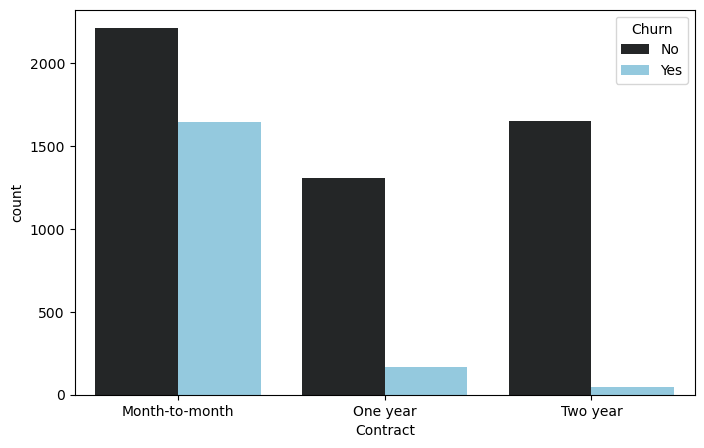

In [43]:
# Churn vs Contract Type
plt.figure(figsize=(8,5))

sns.countplot(
    x='Contract',
    hue='Churn',
    data=df,
    color='skyblue'
    
)

plt.show()

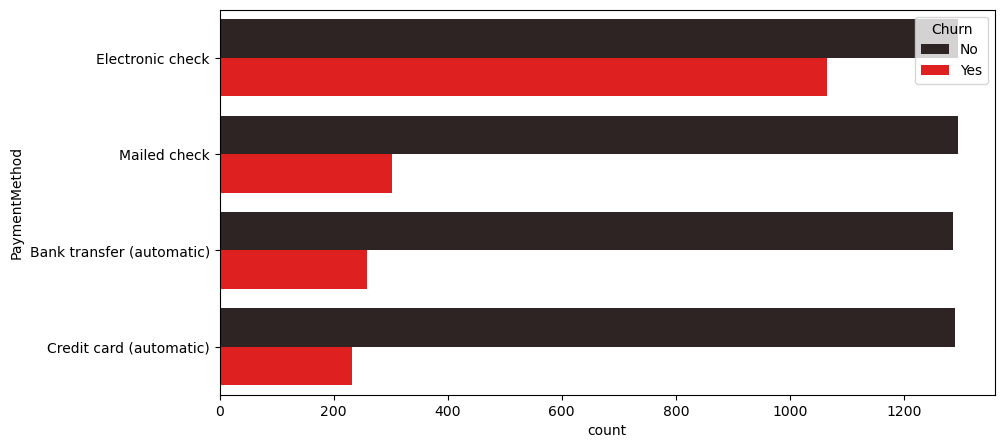

In [44]:
# Churn vs Payment Method
plt.figure(figsize=(10,5))

sns.countplot(
    y='PaymentMethod',
    hue='Churn',
    data=df,
    color='red'
)

plt.show()

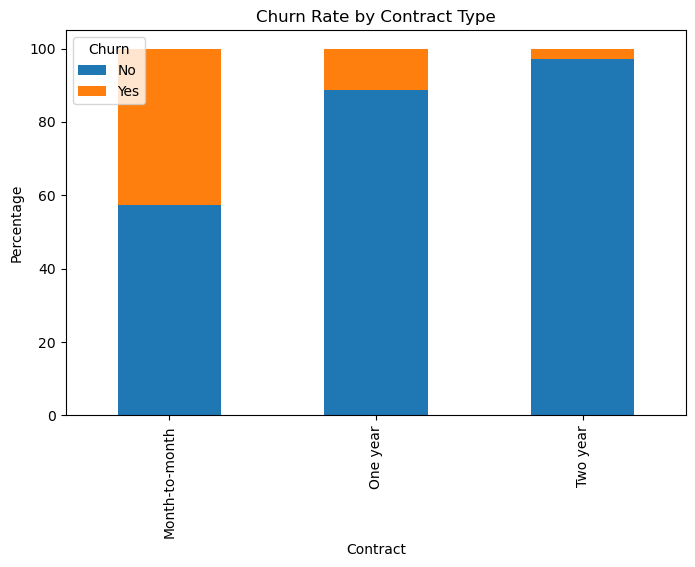

In [45]:
# Churn Percentage by Category
churn_rate = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

churn_rate.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5),
     
   
)

plt.ylabel("Percentage")
plt.title("Churn Rate by Contract Type")
plt.show()

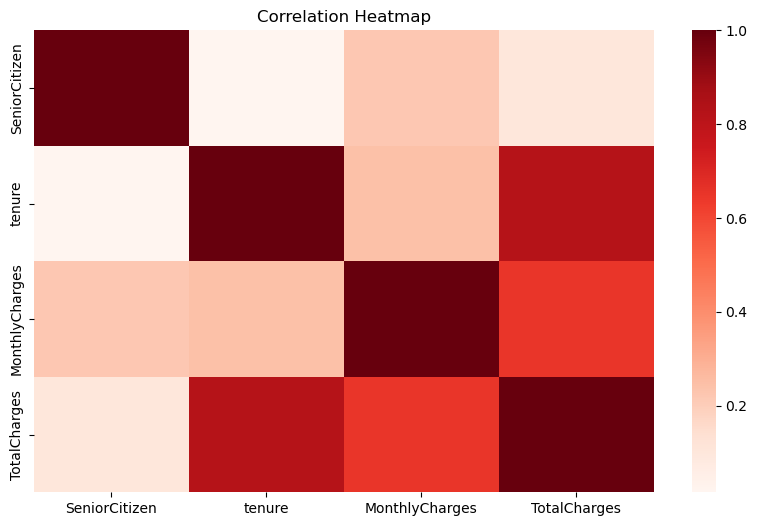

In [46]:
# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap='Reds')
plt.title("Correlation Heatmap")
plt.show()

### 6.Outlier Detection

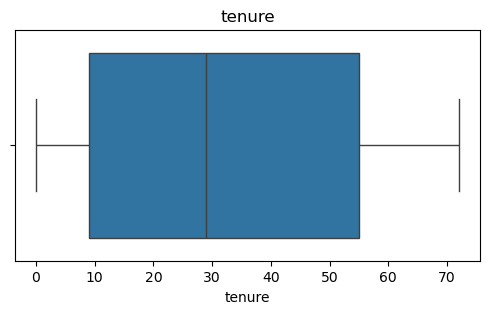

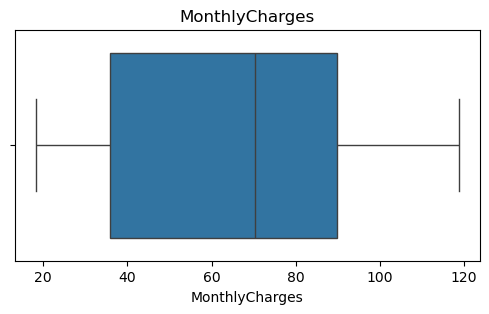

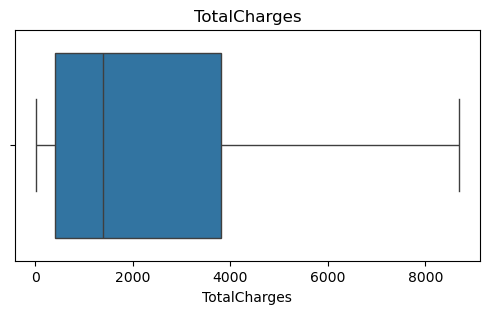

In [47]:
# Boxplots
for col in num_cols:
    
    plt.figure(figsize=(6,3))
    
    sns.boxplot(
        x=df[col]
    )
    
    plt.title(col)
    plt.show()

In [48]:
# IQR Method
def remove_outliers(df, column):

    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return df[
        (df[column] >= lower) &
        (df[column] <= upper)
    ]

# Removing Outliers
for col in num_cols:
    df = remove_outliers(df, col)

### 7.Encode Target Variable

In [49]:
# Mapping
df['Churn'] = df['Churn'].map({
    'No': 0,
    'Yes': 1
})

### 8.Train-test split

In [50]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

### 9.Encoding and Scaling

In [51]:
# Identify categorical & numerical columns

cat_cols = X.select_dtypes(include='object').columns.tolist()

num_cols = X.select_dtypes(exclude='object').columns.tolist()

print("Categorical Columns:", cat_cols)
print("Numerical Columns:", num_cols)



# Column Transformer (Preprocessing)

preprocessor = ColumnTransformer(

    transformers=[

        # Scale numerical features
        ('num', StandardScaler(), num_cols),

        # One-hot encode categorical features
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)

    ]
)

Categorical Columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical Columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


### 10.Training & Evaluation of Models

In [64]:
# Define models

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(),

    "Random Forest": RandomForestClassifier(),

    "Gradient Boosting": GradientBoostingClassifier(),

    "KNN": KNeighborsClassifier(),

    "SVM": SVC(),

    "XGBoost": XGBClassifier(eval_metric='logloss')
}


# Train and evaluate models

cv_results = []

for name, model in models.items():
   
    # Create full pipeline
    pipeline = Pipeline([
        # Column Transformer
        ('preprocessor', preprocessor),

        # PCA (Dimensionality reduction)
        ('pca', PCA(n_components=0.95)),
        
        #Model
        ('classifier', model)

    ])

    # Train model
    pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = pipeline.predict(X_test)

    # Cross Validation
    scores = cross_val_score(pipeline,X_train,y_train,cv=5,scoring='roc_auc', n_jobs=-1)

    # Store metrics
    cv_results.append({

        "Model": name,
        "Mean ROC-AUC": scores.mean(),
        "Std": scores.std()
    })

### 11.Comparing and Selecting Best Model

In [65]:
# Results comparison table

cv_df = pd.DataFrame(
    cv_results
)

cv_df.sort_values(

    by='Mean ROC-AUC',

    ascending=False,

    inplace=True
)



# Best model selection

best_model_name = cv_df.iloc[0]['Model']

print("Best Model:", best_model_name)

cv_df

Best Model: Gradient Boosting


,Model,Mean ROC-AUC,Std
3,Gradient Boosting,0.840502,0.009707
0,Logistic Regression,0.837428,0.009285
2,Random Forest,0.814852,0.008969
6,XGBoost,0.807112,0.008345
5,SVM,0.795413,0.013003
4,KNN,0.782538,0.011569
1,Decision Tree,0.641846,0.012337


### 12.HyperParameter Tuning

In [66]:
gb_pipeline = Pipeline([

    ('preprocess', preprocessor),

    ('model', GradientBoostingClassifier(random_state=42))
])


param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [3, 5, 7],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(

    estimator=gb_pipeline,

    param_grid=param_grid,

    cv=5,

    scoring='roc_auc',

    n_jobs=-1,

    verbose=2
)

grid_search.fit(X_train, y_train)

#Best Model
best_gb_model = grid_search.best_estimator_

print(grid_search.best_params_)

Fitting 5 folds for each of 486 candidates, totalling 2430 fits
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2, 'model__n_estimators': 100, 'model__subsample': 0.8}


### 13.Final Evaluation

In [67]:
y_pred = best_gb_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred)*100)

print(classification_report(y_test, y_pred))

Test Accuracy: 80.0
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.66      0.49      0.57       372

    accuracy                           0.80      1405
   macro avg       0.75      0.70      0.72      1405
weighted avg       0.79      0.80      0.79      1405



### 14.Confusion matrix

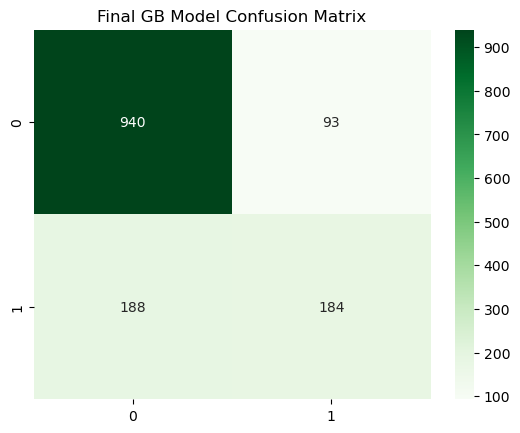

In [68]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')

plt.title("Final GB Model Confusion Matrix")

plt.show()

### 15.Saving Final Model

In [69]:
import joblib

joblib.dump(best_gb_model, "gb_churn_model.pkl")
# model = joblib.load("gb _churn_model.pkl")

['gb_churn_model.pkl']